# 21 - Attention as expected free energy: sampling driven by prediction error

Where each agent looks (the per-channel evidential precision $\rho_k$ fed to
`fisher_deposit_weighted`) is no longer an imposed gate. Under `precision_mode="efe"` it is the
sampling policy that minimises **expected free energy** -- a uniform functional on the belief net
(`src/structural/efe.py`), with two prediction-error drivers that are the same object differing
only in the "other" model your prediction is differenced against:

- **agent $\leftrightarrow$ world** (`epistemic_weight`): your own predictive uncertainty
  $1/\Pi_{vv}$. Look where *you* are uncertain. This **self-seals** -- it vanishes as you grow
  confident, so a confident-but-wrong agent stops sampling the node that would correct it.
- **agent $\leftrightarrow$ neighbour** (`social_weight`): the trust- and confidence-weighted
  disagreement $\sum_j W_{ij}\,\Pi_{j,vv}\,(\mu_{j,v}-\mu_{i,v})^2$ -- the structural
  `surprisal_matrix`. It does **not** depend on your own certainty, so it can re-open a channel you
  abandoned: a trusted peer who looked injects a prediction error through the door you left open
  (trust), not the one you nailed shut (your own attention).

The "vanguard" is just a sub-population initialised from the **oxygen** prior (already measured, so
they disagree on the anomaly node). No new mechanism -- the disagreement *is* the social term.

See `notes/efe_attention.tex` for the derivation. This notebook reports what the model actually
does -- including a finding that runs against the naive hope.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, dataclasses
import matplotlib.pyplot as plt
import jax
from src.structural.phlogiston import StructuralConfig
from src.structural import efe, observables as obs, phlogiston as ph, step as S
from src.structural.kernel import Network
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
KEY = jax.random.PRNGKey(0)

def final_m(cfg, groups):
    f = Network.init(cfg, KEY, groups=groups).run_final()
    return float(obs.order_parameter(f.agents.Pi, f.agents.h, cfg.node_names,
                 ph.DISAGREEMENT_NODES, cfg.mu_phlog_mass, cfg.mu_oxy_mass))
print('imports OK')

imports OK


## 1. The mechanism and the back-compat anchor

The two drivers are closed-form reads off the belief net (the diagonal $\Pi_{vv}$ -- no matrix
inverse, robust to the improper phlogiston prior). The allocation adds the epistemic drive on top of
the *pragmatic* baseline (`precision_mode="derived"`, the suppressive core-coupling gain) and clips
at $\rho_{\max}$, so it can only **re-open** a suppressed channel, never exceed the ceiling. With both
weights $0$ it is byte-identical to `derived` -- the anchor that keeps all prior results intact.

In [2]:
# back-compat anchor: efe at zero weights == derived, byte-for-byte, over a full rollout
cfg_d = StructuralConfig(n_agents=20, n_steps=40, precision_mode='derived', core_governance=80.0)
cfg_e = dataclasses.replace(cfg_d, precision_mode='efe', epistemic_weight=0.0, social_weight=0.0)
fd = S.run_final(cfg_d, S.init_state(cfg_d, KEY))
fe = S.run_final(cfg_e, S.init_state(cfg_e, KEY))
print('efe@0 == derived :', bool(np.allclose(fd.Pi, fe.Pi)) and bool(np.allclose(fd.h, fe.h)))

# the social term fires only on a channel where a trusted, confident neighbour disagrees
mu = np.array([[0.,0.],[2.,0.]]); Pi = np.stack([np.diag([1.,1.]), np.diag([8.,1.])])
import jax.numpy as jnp
pe = efe.social_surprisal(jnp.asarray(mu), jnp.asarray(Pi),
                          jnp.array([[.5,.5],[.5,.5]]), jnp.array([0,1]))
print('social surprisal (agent 0): node0 (neighbour disagrees) = %.2f, node1 (agree) = %.2f'
      % (float(pe[0,0]), float(pe[0,1])))

efe@0 == derived : True


social surprisal (agent 0): node0 (neighbour disagrees) = 16.00, node1 (agree) = 0.00


## 2. E1 -- the two contagions (social term x vanguard)

A self-sealed phlogiston population (`core_governance=200`) with Gaussian within-group spread. We
cross **social term** $\{0,4\}$ with **vanguard present?** $\{$8 oxygen agents, none$\}$, all on the
*same* fused trust graph. Naive hope: vanguard + social term drives oxygen adoption up. The model
disagrees.

E1 2x2  (final m; >0.5 = oxygen adopted)
                  social_w=0   social_w=4


  with vanguard      0.576        0.327


  no vanguard        0.504        0.408


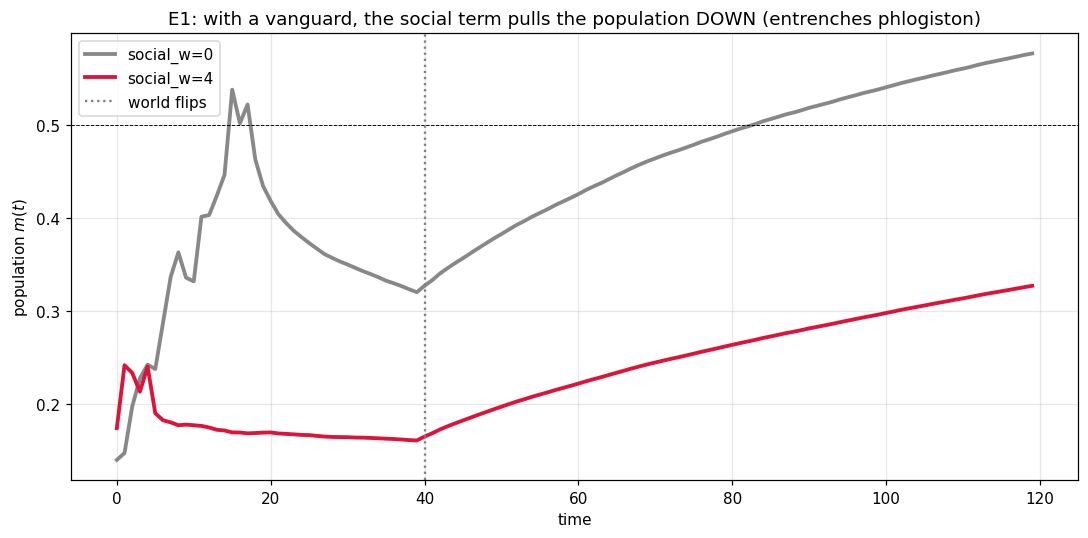

In [3]:
base = StructuralConfig(n_agents=60, n_steps=120, t_shift=40, precision_mode='efe',
                        epistemic_weight=0.2, core_governance=200.0)
van  = [{'count':8,'paradigm':'oxygen','prec_scale':4.0,'stance_sd':0.2},
        {'count':52,'paradigm':'phlogiston','stance':-1.0,'stance_sd':0.3}]
none = [{'count':60,'paradigm':'phlogiston','stance':-1.0,'stance_sd':0.3}]

print('E1 2x2  (final m; >0.5 = oxygen adopted)')
print('                  social_w=0   social_w=4')
grid = {}
for lab, g in [('with vanguard', van), ('no vanguard  ', none)]:
    m0 = final_m(dataclasses.replace(base, social_weight=0.0), g)
    m1 = final_m(dataclasses.replace(base, social_weight=4.0), g)
    grid[lab] = (m0, m1)
    print(f'  {lab}      {m0:.3f}        {m1:.3f}')

# time-resolved: adoption curves make the mechanism visible
fig, ax = plt.subplots(figsize=(10,5))
for sw, c in [(0.0,'#888'), (4.0,'crimson')]:
    cfg = dataclasses.replace(base, social_weight=sw)
    oxy = Network.init(cfg, KEY, groups=van).run_trace_index()   # (T,N)
    ax.plot(np.arange(cfg.n_steps), oxy.mean(axis=1), color=c, lw=2.5,
            label=f'social_w={sw:.0f}')
ax.axhline(0.5,color='k',lw=.6,ls='--'); ax.axvline(base.t_shift,color='grey',ls=':',label='world flips')
ax.set_xlabel('time'); ax.set_ylabel('population $m(t)$'); ax.legend(loc='upper left')
ax.set_title('E1: with a vanguard, the social term pulls the population DOWN (entrenches phlogiston)')
plt.tight_layout(); plt.show()

## 3. The finding: social attention amplifies the *current* regime

Why does "go look" backfire? The social term raises sampling on the disagreement channel from $t=0$
-- including the whole **phlogiston regime** ($t<t_{\text{shift}}$), where the world's gravimetric
data actually *confirm* phlogiston. Heavy early sampling entrenches the incumbents before the anomaly
exists. The term is regime-agnostic: it pours fuel on whichever paradigm the current data favour.

Test: sweep $t_{\text{shift}}$. When the world is already in the oxygen regime ($t_{\text{shift}}=0$)
the social term **helps**; the longer the incumbent-favourable regime runs first, the more it
**backfires**. The sign flips at the regime boundary.

 t_shift   social_w=0   social_w=4   social effect


     0      0.865        0.888       +0.023


    10      0.771        0.511       -0.260


    20      0.699        0.413       -0.286


    40      0.576        0.327       -0.249


    80      0.371        0.221       -0.150


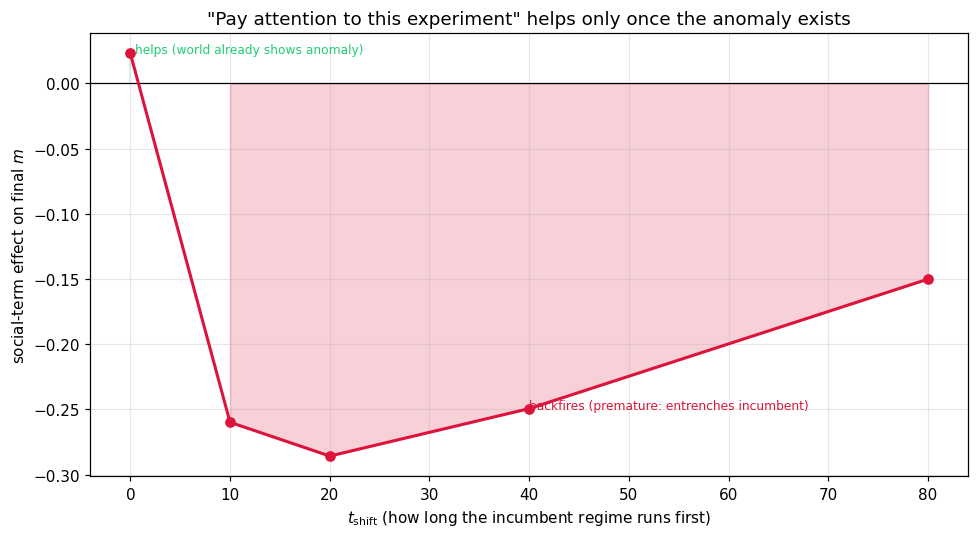

In [4]:
print(' t_shift   social_w=0   social_w=4   social effect')
ts_grid = [0, 10, 20, 40, 80]; d0, d1 = [], []
for ts in ts_grid:
    b = dataclasses.replace(base, t_shift=ts)
    m0 = final_m(dataclasses.replace(b, social_weight=0.0), van)
    m1 = final_m(dataclasses.replace(b, social_weight=4.0), van)
    d0.append(m0); d1.append(m1)
    print(f'   {ts:3d}      {m0:.3f}        {m1:.3f}       {m1-m0:+.3f}')

fig, ax = plt.subplots(figsize=(9,5))
eff = np.array(d1) - np.array(d0)
ax.axhline(0, color='k', lw=.8)
ax.plot(ts_grid, eff, 'o-', color='crimson', lw=2)
ax.fill_between(ts_grid, 0, eff, where=eff>0, color='#2c7', alpha=.2)
ax.fill_between(ts_grid, 0, eff, where=eff<0, color='crimson', alpha=.2)
ax.annotate('helps (world already shows anomaly)', (0, eff[0]), fontsize=8, color='#2c7',
            xytext=(3,0.03), textcoords='offset points')
ax.annotate('backfires (premature: entrenches incumbent)', (40, eff[3]), fontsize=8, color='crimson')
ax.set_xlabel('$t_{\\mathrm{shift}}$ (how long the incumbent regime runs first)')
ax.set_ylabel('social-term effect on final $m$')
ax.set_title('"Pay attention to this experiment" helps only once the anomaly exists')
plt.tight_layout(); plt.show()

## 4. E3 -- the BMR canary

`run_trace_bmr` exposes the population-mean Bayesian Model Reduction factor $\Delta F$ for
phlogiston's falsifiable commitment ("the calx is lighter"): $\Delta F>0$ vindicated, $<0$ refuted.
Under heavy self-sealing the committed bloc stops sampling the gravimetric channel, so $\Delta F$
should be slow to turn negative -- the refutation is *invisible* to a paradigm that has stopped
looking. We contrast a self-sealed population (`core_governance` high) with an attentive one.

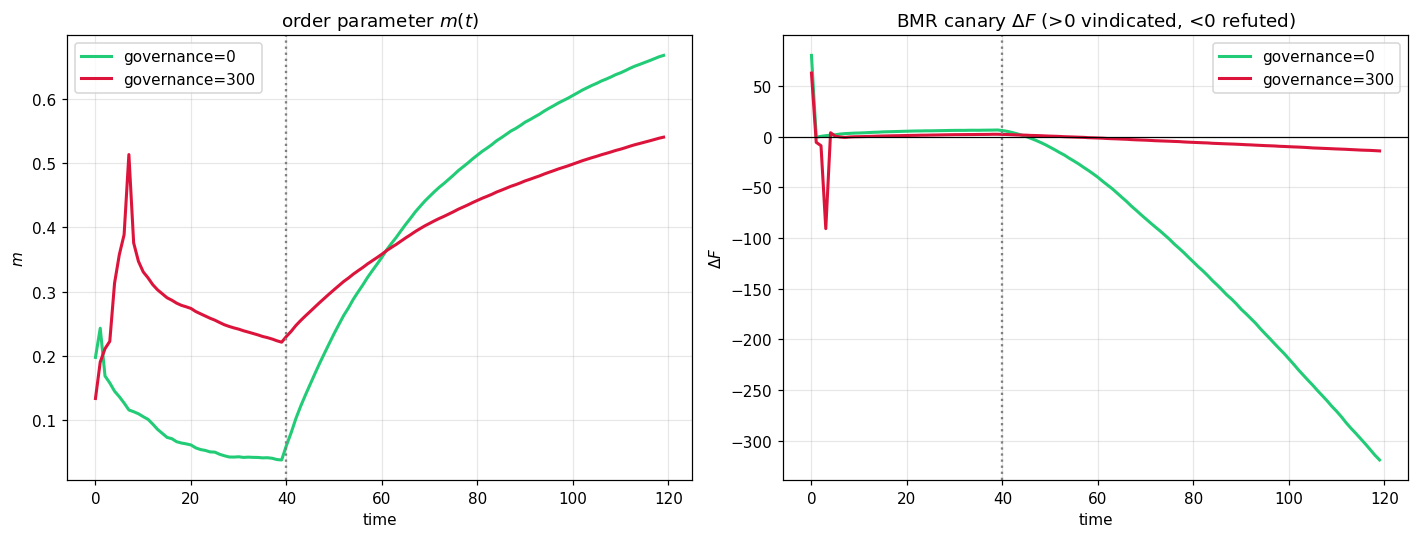

A self-sealed bloc (high governance) is slower to register the refutation: it stopped looking.


In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13,5))
for gov, c in [(0.0,'#2c7'), (300.0,'crimson')]:
    cfg = dataclasses.replace(base, core_governance=gov, social_weight=0.0, epistemic_weight=0.5)
    m_t, dF_t = Network.init(cfg, KEY, groups=van).run_trace_bmr()
    t = np.arange(cfg.n_steps)
    axL.plot(t, m_t, color=c, lw=2, label=f'governance={gov:.0f}')
    axR.plot(t, dF_t, color=c, lw=2, label=f'governance={gov:.0f}')
for ax, ttl, yl in [(axL,'order parameter $m(t)$','$m$'),
                    (axR,"BMR canary $\\Delta F$ (>0 vindicated, <0 refuted)",'$\\Delta F$')]:
    ax.axvline(base.t_shift, color='grey', ls=':'); ax.set_xlabel('time')
    ax.set_ylabel(yl); ax.set_title(ttl); ax.legend(loc='best')
axR.axhline(0, color='k', lw=.8)
plt.tight_layout(); plt.show()
print('A self-sealed bloc (high governance) is slower to register the refutation: it stopped looking.')

## 5. Summary -- and the honest open question

- **The mechanism works as designed and is byte-compatible.** `precision_mode="efe"` adds the two
  prediction-error drives over the existing pragmatic baseline; at zero weights it *is* `derived`.
  The social term is the structural `surprisal_matrix`, and it provably fires only where a trusted,
  confident neighbour disagrees (unit test) -- independent of the agent's own certainty, the property
  that *could* break self-sealing.
- **But the social term is double-edged.** It amplifies sampling on the contested channel regardless
  of regime, so it accelerates whichever paradigm the *current* data favour. A vanguard who is right
  but **premature** -- pointing at the gravimetric experiment before the world reveals the anomaly --
  *entrenches* the orthodoxy it opposes (E1, the timing sweep). "Go look" helps only once there is
  something anomalous to see.
- **The early-warning canary self-seals (E3):** a high-governance bloc registers the BMR refutation
  later, because it has stopped sampling the channel that carries it.

**Open question (the next conversation).** To make a trusted peer *break* lock-in rather than harden
it, the social drive likely needs to be **conditioned on present prediction error from the world**,
not on a static stance disagreement -- i.e. the peer's "look here" should carry weight only when the
peer's own recent observations were surprising. Equivalently, the substrate may need **forgetting**
(a precision leak) so the incumbents' confidence does not ratchet during the pre-anomaly regime. Both
are small, principled extensions; which one the model needs is the thing to test next. Either way, the
result here is real: *attention contagion is not automatically emancipatory.*